# Signal Research Notebook

Interactive research and development notebook for signal creation and testing.

## Workflow
1. **Load & Explore Data** - Load market data and inspect distributions
2. **Develop Signal** - Build and test signal logic interactively
3. **Implement** - Copy validated logic to `create_signal.py`
4. **Execute** - Run `uv run create-signal` to generate `data/signal.parquet`
5. **Validate Signal** - use `uv run ew-dash` to view signal characteristics.
6. **Backtest** - Use `uv run backtest` for slurm backtest on super computer
7. **Performance** - Use `uv run opt-dash` for in depth analysis of mvo backtested signal.

## Tips
- Use cells to isolate different aspects of your signal
- Modify parameters directly in cells to test variations
- Check signal statistics regularly to catch issues early
- Document your assumptions and findings as you develop

## Setup

In [23]:
import polars as pl
import numpy as np
import datetime as dt
import sf_quant.data as sfd
import sf_quant.research as sfr
import polars_ols

## 1. Load & Explore Data

Load your market data and inspect key characteristics before developing the signal.

In [24]:
# Configurations

industry_cols = [
    "date",
    "barrid",
    "USSLOWL_AERODEF",
    "USSLOWL_AIRLINES",
    "USSLOWL_ALUMSTEL",
    "USSLOWL_APPAREL",
    "USSLOWL_AUTO",
    "USSLOWL_BANKS",
    "USSLOWL_BEVTOB",
    "USSLOWL_BIOLIFE",
    "USSLOWL_BLDGPROD",
    "USSLOWL_CHEM",
    "USSLOWL_CNSTENG",
    "USSLOWL_CNSTMACH",
    "USSLOWL_CNSTMATL",
    "USSLOWL_COMMEQP",
    "USSLOWL_COMPELEC",
    "USSLOWL_COMSVCS",
    "USSLOWL_CONGLOM",
    "USSLOWL_CONTAINR",
    "USSLOWL_DISTRIB",
    "USSLOWL_DIVFIN",
    "USSLOWL_ELECEQP",
    "USSLOWL_ELECUTIL",
    "USSLOWL_FOODPROD",
    "USSLOWL_FOODRET",
    "USSLOWL_GASUTIL",
    "USSLOWL_HLTHEQP",
    "USSLOWL_HLTHSVCS",
    "USSLOWL_HOMEBLDG",
    "USSLOWL_HOUSEDUR",
    "USSLOWL_INDMACH",
    "USSLOWL_INSURNCE",
    "USSLOWL_INTERNET",
    "USSLOWL_LEISPROD",
    "USSLOWL_LEISSVCS",
    "USSLOWL_LIFEINS",
    "USSLOWL_MEDIA",
    "USSLOWL_MGDHLTH",
    "USSLOWL_MULTUTIL",
    "USSLOWL_OILGSCON",
    "USSLOWL_OILGSDRL",
    "USSLOWL_OILGSEQP",
    "USSLOWL_OILGSEXP",
    "USSLOWL_PAPER",
    "USSLOWL_PHARMA",
    "USSLOWL_PRECMTLS",
    "USSLOWL_PSNLPROD",
    "USSLOWL_REALEST",
    "USSLOWL_RESTAUR",
    "USSLOWL_ROADRAIL",
    "USSLOWL_SEMICOND",
    "USSLOWL_SEMIEQP",
    "USSLOWL_SOFTWARE",
    "USSLOWL_SPLTYRET",
    "USSLOWL_SPTYCHEM",
    "USSLOWL_SPTYSTOR",
    "USSLOWL_TELECOM",
    "USSLOWL_TRADECO",
    "USSLOWL_TRANSPRT",
    "USSLOWL_WIRELESS",
]

start = dt.date(2000, 1, 1)
end = dt.date(2010, 12, 31)

asset_columns = [
    'barrid', 
    'date', 
    'predicted_beta', 
    'return', 
    'specific_risk',
    'price'
]


In [25]:
# Create Industry_exposure_df
# 0 indicates that stock is NOT in the industry and 1 indicates the stock IS in the industry
industry_exposures_df = sfd.load_exposures(
    start=start, 
    end=end, 
    in_universe=True,
    columns=industry_cols
)

industry_only = [c for c in industry_cols if c not in ["date", "barrid"]]

industry_exposures_df = industry_exposures_df.with_columns(
    pl.when(pl.col(c).is_null()).then(pl.lit(0)).otherwise(pl.lit(1)).cast(pl.Int8).alias(c)
    for c in industry_only
)


industry_exposures_df

date,barrid,USSLOWL_AERODEF,USSLOWL_AIRLINES,USSLOWL_ALUMSTEL,USSLOWL_APPAREL,USSLOWL_AUTO,USSLOWL_BANKS,USSLOWL_BEVTOB,USSLOWL_BIOLIFE,USSLOWL_BLDGPROD,USSLOWL_CHEM,USSLOWL_CNSTENG,USSLOWL_CNSTMACH,USSLOWL_CNSTMATL,USSLOWL_COMMEQP,USSLOWL_COMPELEC,USSLOWL_COMSVCS,USSLOWL_CONGLOM,USSLOWL_CONTAINR,USSLOWL_DISTRIB,USSLOWL_DIVFIN,USSLOWL_ELECEQP,USSLOWL_ELECUTIL,USSLOWL_FOODPROD,USSLOWL_FOODRET,USSLOWL_GASUTIL,USSLOWL_HLTHEQP,USSLOWL_HLTHSVCS,USSLOWL_HOMEBLDG,USSLOWL_HOUSEDUR,USSLOWL_INDMACH,USSLOWL_INSURNCE,USSLOWL_INTERNET,USSLOWL_LEISPROD,USSLOWL_LEISSVCS,USSLOWL_LIFEINS,USSLOWL_MEDIA,USSLOWL_MGDHLTH,USSLOWL_MULTUTIL,USSLOWL_OILGSCON,USSLOWL_OILGSDRL,USSLOWL_OILGSEQP,USSLOWL_OILGSEXP,USSLOWL_PAPER,USSLOWL_PHARMA,USSLOWL_PRECMTLS,USSLOWL_PSNLPROD,USSLOWL_REALEST,USSLOWL_RESTAUR,USSLOWL_ROADRAIL,USSLOWL_SEMICOND,USSLOWL_SEMIEQP,USSLOWL_SOFTWARE,USSLOWL_SPLTYRET,USSLOWL_SPTYCHEM,USSLOWL_SPTYSTOR,USSLOWL_TELECOM,USSLOWL_TRADECO,USSLOWL_TRANSPRT,USSLOWL_WIRELESS
date,str,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8
2000-06-30,"""USA1151""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2000-07-03,"""USA1151""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2000-07-05,"""USA1151""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2000-07-06,"""USA1151""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2000-07-07,"""USA1151""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2010-12-27,"""USAZZY1""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2010-12-28,"""USAZZY1""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2010-12-29,"""USAZZY1""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [26]:
# create the assets data frame

assets_df = sfd.load_assets(
    start=start,
    end=end,
    columns=asset_columns,
    in_universe=True,
)

assets_df

barrid,date,predicted_beta,return,specific_risk,price
str,date,f64,f64,f64,f64
"""USA1151""",2000-06-30,1.917824,6.75,121.589369,53.375
"""USA1151""",2000-07-03,1.931048,3.1616,121.863016,55.0625
"""USA1151""",2000-07-05,1.922297,4.4268,121.069446,57.5
"""USA1151""",2000-07-06,1.91551,0.0,120.844525,57.5
"""USA1151""",2000-07-07,1.959908,25.2174,123.086351,72.0
…,…,…,…,…,…
"""USAZZY1""",2010-12-27,2.343898,-0.3158,54.964103,9.47
"""USAZZY1""",2010-12-28,2.338692,-0.2112,54.780081,9.45
"""USAZZY1""",2010-12-29,2.334379,-1.9048,54.7473,9.27


In [27]:
# Perform left merge on assets data frame with indsutry exposure data frame

df = assets_df.join(
    industry_exposures_df, on=['date', 'barrid'], how='left'
    )

# calculate log returns and shift them

df = (df
      .with_columns(
          pl.col('return')
          .truediv(100)
      )
      .with_columns(
          pl.col('return')
          .log1p()
          .alias('logreturn')
      )
      .sort(['date', 'barrid'])
)
df

barrid,date,predicted_beta,return,specific_risk,price,USSLOWL_AERODEF,USSLOWL_AIRLINES,USSLOWL_ALUMSTEL,USSLOWL_APPAREL,USSLOWL_AUTO,USSLOWL_BANKS,USSLOWL_BEVTOB,USSLOWL_BIOLIFE,USSLOWL_BLDGPROD,USSLOWL_CHEM,USSLOWL_CNSTENG,USSLOWL_CNSTMACH,USSLOWL_CNSTMATL,USSLOWL_COMMEQP,USSLOWL_COMPELEC,USSLOWL_COMSVCS,USSLOWL_CONGLOM,USSLOWL_CONTAINR,USSLOWL_DISTRIB,USSLOWL_DIVFIN,USSLOWL_ELECEQP,USSLOWL_ELECUTIL,USSLOWL_FOODPROD,USSLOWL_FOODRET,USSLOWL_GASUTIL,USSLOWL_HLTHEQP,USSLOWL_HLTHSVCS,USSLOWL_HOMEBLDG,USSLOWL_HOUSEDUR,USSLOWL_INDMACH,USSLOWL_INSURNCE,USSLOWL_INTERNET,USSLOWL_LEISPROD,USSLOWL_LEISSVCS,USSLOWL_LIFEINS,USSLOWL_MEDIA,USSLOWL_MGDHLTH,USSLOWL_MULTUTIL,USSLOWL_OILGSCON,USSLOWL_OILGSDRL,USSLOWL_OILGSEQP,USSLOWL_OILGSEXP,USSLOWL_PAPER,USSLOWL_PHARMA,USSLOWL_PRECMTLS,USSLOWL_PSNLPROD,USSLOWL_REALEST,USSLOWL_RESTAUR,USSLOWL_ROADRAIL,USSLOWL_SEMICOND,USSLOWL_SEMIEQP,USSLOWL_SOFTWARE,USSLOWL_SPLTYRET,USSLOWL_SPTYCHEM,USSLOWL_SPTYSTOR,USSLOWL_TELECOM,USSLOWL_TRADECO,USSLOWL_TRANSPRT,USSLOWL_WIRELESS,logreturn
str,date,f64,f64,f64,f64,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,f64
"""USA11I1""",2000-01-03,2.09748,0.128308,89.215875,141.25,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0.120719
"""USA11Q1""",2000-01-03,1.772688,-0.012739,121.030442,77.5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,-0.012821
"""USA12J1""",2000-01-03,0.437592,-0.01227,41.450374,10.0625,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-0.012346
"""USA12Z1""",2000-01-03,1.810051,0.007481,112.485013,25.25,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.007453
"""USA14R1""",2000-01-03,1.528935,0.031667,109.985703,38.6875,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.031176
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""USAZWD1""",2010-12-31,1.143691,-0.004051,30.263909,34.42,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-0.004059
"""USAZWU1""",2010-12-31,0.992659,-0.006787,24.00956,13.17,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-0.00681
"""USAZX92""",2010-12-31,1.371162,-0.002317,39.327084,12.92,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,-0.00232


In [28]:
long = (
    df
    .unpivot(
        on=industry_only,          # columns to melt
        index=["barrid", "date", "return", "predicted_beta", "specific_risk", "price"],  # columns to keep as-is
        variable_name="industry",
        value_name="val",
    )
    .filter(pl.col("val") == 1)    # keep only rows where stock IS in that industry
    .drop("val")
    .sort(['date', 'industry'])
)

long

barrid,date,return,predicted_beta,specific_risk,price,industry
str,date,f64,f64,f64,f64,str
"""USAN6I2""",2000-01-03,-0.020857,0.400102,36.258817,52.8125,"""USSLOWL_AERODEF"""
"""USANIH1""",2000-01-03,-0.001996,0.539894,26.095611,31.25,"""USSLOWL_AERODEF"""
"""USAAGR1""",2000-01-03,-0.017335,0.798709,27.724755,56.6875,"""USSLOWL_AERODEF"""
"""USABJM1""",2000-01-03,-0.003831,0.178089,39.965805,16.25,"""USSLOWL_AERODEF"""
"""USABLZ1""",2000-01-03,-0.014815,0.684118,55.515243,8.3125,"""USSLOWL_AERODEF"""
…,…,…,…,…,…,…
"""USAOB21""",2010-12-31,0.016827,1.356327,40.334244,4.23,"""USSLOWL_WIRELESS"""
"""USAPF22""",2010-12-31,0.012536,1.010098,29.014149,17.77,"""USSLOWL_WIRELESS"""
"""USASFR1""",2010-12-31,-0.020397,1.28469,28.639038,18.73,"""USSLOWL_WIRELESS"""


In [29]:
# Create Equal Weight Portfolio

ew_port = (
    long
    .group_by(["date", "industry"])
    .agg(
        pl.col('return').mean().alias("ew_return"),
        )
    .sort(["industry", "date"])
)

ew_port

date,industry,ew_return
date,str,f64
2000-01-03,"""USSLOWL_AERODEF""",-0.025225
2000-01-04,"""USSLOWL_AERODEF""",-0.015004
2000-01-05,"""USSLOWL_AERODEF""",0.010205
2000-01-06,"""USSLOWL_AERODEF""",0.011852
2000-01-07,"""USSLOWL_AERODEF""",0.016321
…,…,…
2010-12-27,"""USSLOWL_WIRELESS""",0.003038
2010-12-28,"""USSLOWL_WIRELESS""",-0.002915
2010-12-29,"""USSLOWL_WIRELESS""",0.004812


In [30]:
# Calculate Momentum

industry_momentum = (
    ew_port
    .sort(['date', 'industry'])
    .with_columns(
        pl.col('ew_return')
        .rolling_sum(window_size=230)
        .over('industry')
        .alias('momentum')
    )
    .with_columns(
        pl.col('momentum')
        .shift(22)
        .over('industry')
    )
)
industry_momentum

date,industry,ew_return,momentum
date,str,f64,f64
2000-01-03,"""USSLOWL_AERODEF""",-0.025225,null
2000-01-03,"""USSLOWL_AIRLINES""",-0.000769,null
2000-01-03,"""USSLOWL_ALUMSTEL""",-0.021475,null
2000-01-03,"""USSLOWL_APPAREL""",-0.021297,null
2000-01-03,"""USSLOWL_AUTO""",-0.019564,null
…,…,…,…
2010-12-31,"""USSLOWL_SPTYSTOR""",-0.013982,0.258663
2010-12-31,"""USSLOWL_TELECOM""",-0.002342,0.113611
2010-12-31,"""USSLOWL_TRADECO""",-0.004961,0.315415


In [31]:
# go back to stock space and filter price

long = (long
        .join(industry_momentum, on=['date', 'industry'], how='left')
        .filter(pl.col('price') >= 5)
        )
long

barrid,date,return,predicted_beta,specific_risk,price,industry,ew_return,momentum
str,date,f64,f64,f64,f64,str,f64,f64
"""USAN6I2""",2000-01-03,-0.020857,0.400102,36.258817,52.8125,"""USSLOWL_AERODEF""",-0.025225,null
"""USANIH1""",2000-01-03,-0.001996,0.539894,26.095611,31.25,"""USSLOWL_AERODEF""",-0.025225,null
"""USAAGR1""",2000-01-03,-0.017335,0.798709,27.724755,56.6875,"""USSLOWL_AERODEF""",-0.025225,null
"""USABJM1""",2000-01-03,-0.003831,0.178089,39.965805,16.25,"""USSLOWL_AERODEF""",-0.025225,null
"""USABLZ1""",2000-01-03,-0.014815,0.684118,55.515243,8.3125,"""USSLOWL_AERODEF""",-0.025225,null
…,…,…,…,…,…,…,…,…
"""USAO921""",2010-12-31,0.00261,0.695155,23.112453,49.94,"""USSLOWL_WIRELESS""",-0.00054,0.147014
"""USAPF22""",2010-12-31,0.012536,1.010098,29.014149,17.77,"""USSLOWL_WIRELESS""",-0.00054,0.147014
"""USASFR1""",2010-12-31,-0.020397,1.28469,28.639038,18.73,"""USSLOWL_WIRELESS""",-0.00054,0.147014


In [32]:
# z-score momentum

industry_momentum = long.with_columns(
    ((pl.col("momentum") - pl.col("momentum").mean().over("date")) / 
      pl.col("momentum").std().over("date"))
    .alias("score")
)

industry_momentum


barrid,date,return,predicted_beta,specific_risk,price,industry,ew_return,momentum,score
str,date,f64,f64,f64,f64,str,f64,f64,f64
"""USAN6I2""",2000-01-03,-0.020857,0.400102,36.258817,52.8125,"""USSLOWL_AERODEF""",-0.025225,null,null
"""USANIH1""",2000-01-03,-0.001996,0.539894,26.095611,31.25,"""USSLOWL_AERODEF""",-0.025225,null,null
"""USAAGR1""",2000-01-03,-0.017335,0.798709,27.724755,56.6875,"""USSLOWL_AERODEF""",-0.025225,null,null
"""USABJM1""",2000-01-03,-0.003831,0.178089,39.965805,16.25,"""USSLOWL_AERODEF""",-0.025225,null,null
"""USABLZ1""",2000-01-03,-0.014815,0.684118,55.515243,8.3125,"""USSLOWL_AERODEF""",-0.025225,null,null
…,…,…,…,…,…,…,…,…,…
"""USAO921""",2010-12-31,0.00261,0.695155,23.112453,49.94,"""USSLOWL_WIRELESS""",-0.00054,0.147014,-0.543077
"""USAPF22""",2010-12-31,0.012536,1.010098,29.014149,17.77,"""USSLOWL_WIRELESS""",-0.00054,0.147014,-0.543077
"""USASFR1""",2010-12-31,-0.020397,1.28469,28.639038,18.73,"""USSLOWL_WIRELESS""",-0.00054,0.147014,-0.543077


In [33]:
# compute alpha

industry_momentum = (
    industry_momentum
    .with_columns(
        pl.col('specific_risk')
        .truediv(100)
    )
    .with_columns(
        pl.col('score')
        .mul(.05)
        .mul(pl.col('specific_risk'))
        .alias('alpha')
    )
)

industry_momentum

barrid,date,return,predicted_beta,specific_risk,price,industry,ew_return,momentum,score,alpha
str,date,f64,f64,f64,f64,str,f64,f64,f64,f64
"""USAN6I2""",2000-01-03,-0.020857,0.400102,0.362588,52.8125,"""USSLOWL_AERODEF""",-0.025225,null,null,null
"""USANIH1""",2000-01-03,-0.001996,0.539894,0.260956,31.25,"""USSLOWL_AERODEF""",-0.025225,null,null,null
"""USAAGR1""",2000-01-03,-0.017335,0.798709,0.277248,56.6875,"""USSLOWL_AERODEF""",-0.025225,null,null,null
"""USABJM1""",2000-01-03,-0.003831,0.178089,0.399658,16.25,"""USSLOWL_AERODEF""",-0.025225,null,null,null
"""USABLZ1""",2000-01-03,-0.014815,0.684118,0.555152,8.3125,"""USSLOWL_AERODEF""",-0.025225,null,null,null
…,…,…,…,…,…,…,…,…,…,…
"""USAO921""",2010-12-31,0.00261,0.695155,0.231125,49.94,"""USSLOWL_WIRELESS""",-0.00054,0.147014,-0.543077,-0.006276
"""USAPF22""",2010-12-31,0.012536,1.010098,0.290141,17.77,"""USSLOWL_WIRELESS""",-0.00054,0.147014,-0.543077,-0.007878
"""USASFR1""",2010-12-31,-0.020397,1.28469,0.28639,18.73,"""USSLOWL_WIRELESS""",-0.00054,0.147014,-0.543077,-0.007777


In [ ]:
def load_data() -> pl.DataFrame:
    # Configurations

    industry_cols = [
        "date",
        "barrid",
        "USSLOWL_AERODEF",
        "USSLOWL_AIRLINES",
        "USSLOWL_ALUMSTEL",
        "USSLOWL_APPAREL",
        "USSLOWL_AUTO",
        "USSLOWL_BANKS",
        "USSLOWL_BEVTOB",
        "USSLOWL_BIOLIFE",
        "USSLOWL_BLDGPROD",
        "USSLOWL_CHEM",
        "USSLOWL_CNSTENG",
        "USSLOWL_CNSTMACH",
        "USSLOWL_CNSTMATL",
        "USSLOWL_COMMEQP",
        "USSLOWL_COMPELEC",
        "USSLOWL_COMSVCS",
        "USSLOWL_CONGLOM",
        "USSLOWL_CONTAINR",
        "USSLOWL_DISTRIB",
        "USSLOWL_DIVFIN",
        "USSLOWL_ELECEQP",
        "USSLOWL_ELECUTIL",
        "USSLOWL_FOODPROD",
        "USSLOWL_FOODRET",
        "USSLOWL_GASUTIL",
        "USSLOWL_HLTHEQP",
        "USSLOWL_HLTHSVCS",
        "USSLOWL_HOMEBLDG",
        "USSLOWL_HOUSEDUR",
        "USSLOWL_INDMACH",
        "USSLOWL_INSURNCE",
        "USSLOWL_INTERNET",
        "USSLOWL_LEISPROD",
        "USSLOWL_LEISSVCS",
        "USSLOWL_LIFEINS",
        "USSLOWL_MEDIA",
        "USSLOWL_MGDHLTH",
        "USSLOWL_MULTUTIL",
        "USSLOWL_OILGSCON",
        "USSLOWL_OILGSDRL",
        "USSLOWL_OILGSEQP",
        "USSLOWL_OILGSEXP",
        "USSLOWL_PAPER",
        "USSLOWL_PHARMA",
        "USSLOWL_PRECMTLS",
        "USSLOWL_PSNLPROD",
        "USSLOWL_REALEST",
        "USSLOWL_RESTAUR",
        "USSLOWL_ROADRAIL",
        "USSLOWL_SEMICOND",
        "USSLOWL_SEMIEQP",
        "USSLOWL_SOFTWARE",
        "USSLOWL_SPLTYRET",
        "USSLOWL_SPTYCHEM",
        "USSLOWL_SPTYSTOR",
        "USSLOWL_TELECOM",
        "USSLOWL_TRADECO",
        "USSLOWL_TRANSPRT",
        "USSLOWL_WIRELESS",
    ]

    start = dt.date(2000, 1, 1)
    end = dt.date(2010, 12, 31)

    asset_columns = [
        'barrid', 
        'date', 
        'predicted_beta', 
        'return', 
        'specific_risk',
        'price'
    ]


    # Create Industry_exposure_df
    # 0 indicates that stock is NOT in the industry and 1 indicates the stock IS in the industry
    
    industry_exposures_df = sfd.load_exposures(
        start=start, 
        end=end, 
        in_universe=True,
        columns=industry_cols
    )

    industry_only = [c for c in industry_cols if c not in ["date", "barrid"]]

    industry_exposures_df = industry_exposures_df.with_columns(
        pl.when(pl.col(c).is_null()).then(pl.lit(0)).otherwise(pl.lit(1)).cast(pl.Int8).alias(c)
        for c in industry_only
    )

    # create the assets data frame

    assets_df = sfd.load_assets(
        start=start,
        end=end,
        columns=asset_columns,
        in_universe=True,
    )

    # Perform left merge on assets data frame with indsutry exposure data frame

    df = assets_df.join(
        industry_exposures_df, on=['date', 'barrid'], how='left'
        )

    # calculate log returns and shift them

    df = (df
        .with_columns(
            pl.col('return')
            .truediv(100)
        )
        .with_columns(
            pl.col('specific_risk')
            .truediv(100)
        )
        .with_columns(
            pl.col('return')
            .log1p()
            .alias('logreturn')
        )
        .sort(['date', 'barrid'])
    )

    # group by industry
    
    long = (
        df
        .unpivot(
            on=industry_only,          # columns to melt
            index=["barrid", "date", "return", "predicted_beta", "specific_risk", "price"],  # columns to keep as-is
            variable_name="industry",
            value_name="val",
        )
        .filter(pl.col("val") == 1)    # keep only rows where stock IS in that industry
        .drop("val")
        .sort(['date', 'industry'])
    )

    # Create Equal Weight Portfolio

    ew_port = (
        long
        .group_by(["date", "industry"])
        .agg(
            pl.col('return').mean().alias("ew_return"),
            )
        .sort(["industry", "date"])
    )

    return ew_port, long

ew_port, long = load_data()



barrid,date,return,predicted_beta,specific_risk,price,industry
str,date,f64,f64,f64,f64,str
"""USAN6I2""",2000-01-03,-0.020857,0.400102,0.362588,52.8125,"""USSLOWL_AERODEF"""
"""USANIH1""",2000-01-03,-0.001996,0.539894,0.260956,31.25,"""USSLOWL_AERODEF"""
"""USAAGR1""",2000-01-03,-0.017335,0.798709,0.277248,56.6875,"""USSLOWL_AERODEF"""
"""USABJM1""",2000-01-03,-0.003831,0.178089,0.399658,16.25,"""USSLOWL_AERODEF"""
"""USABLZ1""",2000-01-03,-0.014815,0.684118,0.555152,8.3125,"""USSLOWL_AERODEF"""
…,…,…,…,…,…,…
"""USAOB21""",2010-12-31,0.016827,1.356327,0.403342,4.23,"""USSLOWL_WIRELESS"""
"""USAPF22""",2010-12-31,0.012536,1.010098,0.290141,17.77,"""USSLOWL_WIRELESS"""
"""USASFR1""",2010-12-31,-0.020397,1.28469,0.28639,18.73,"""USSLOWL_WIRELESS"""


## 2. Signal Development

Build and test your signal logic. Modify parameters and logic here to find optimal configurations.

In [46]:
def create_signal(df: pl.DataFrame, df2: pl.DataFrame) -> pl.DataFrame:

    ew_port = df
    long = df2
    
    # Calculate Momentum
    

    industry_momentum = (
        ew_port
        .sort(['date', 'industry'])
        .with_columns(
            pl.col('ew_return')
            .rolling_sum(window_size=230)
            .over('industry')
            .alias('momentum')
        )
        .with_columns(
            pl.col('momentum')
            .shift(22)
            .over('industry')
        )
    )
    # go back to stock space and filter price

    long = (long
            .join(industry_momentum, on=['date', 'industry'], how='left')
            .filter(pl.col('price') >= 5)
            )
    
    # z-score momentum

    industry_momentum = long.with_columns(
        ((pl.col("momentum") - pl.col("momentum").mean().over("date")) / 
        pl.col("momentum").std().over("date"))
        .alias("score")
    )
    # compute alpha

    industry_momentum = (
        industry_momentum
        .with_columns(
            pl.col('score')
            .mul(.05)
            .mul(pl.col('specific_risk'))
            .alias('alpha')
        )
    )

    return industry_momentum

    
industry_momentum = create_signal(ew_port, long)
industry_momentum
    


barrid,date,return,predicted_beta,specific_risk,price,industry,ew_return,momentum,score,alpha
str,date,f64,f64,f64,f64,str,f64,f64,f64,f64
"""USAN6I2""",2000-01-03,-0.020857,0.400102,0.362588,52.8125,"""USSLOWL_AERODEF""",-0.025225,null,null,null
"""USANIH1""",2000-01-03,-0.001996,0.539894,0.260956,31.25,"""USSLOWL_AERODEF""",-0.025225,null,null,null
"""USAAGR1""",2000-01-03,-0.017335,0.798709,0.277248,56.6875,"""USSLOWL_AERODEF""",-0.025225,null,null,null
"""USABJM1""",2000-01-03,-0.003831,0.178089,0.399658,16.25,"""USSLOWL_AERODEF""",-0.025225,null,null,null
"""USABLZ1""",2000-01-03,-0.014815,0.684118,0.555152,8.3125,"""USSLOWL_AERODEF""",-0.025225,null,null,null
…,…,…,…,…,…,…,…,…,…,…
"""USAO921""",2010-12-31,0.00261,0.695155,0.231125,49.94,"""USSLOWL_WIRELESS""",-0.00054,0.147014,-0.543077,-0.006276
"""USAPF22""",2010-12-31,0.012536,1.010098,0.290141,17.77,"""USSLOWL_WIRELESS""",-0.00054,0.147014,-0.543077,-0.007878
"""USASFR1""",2010-12-31,-0.020397,1.28469,0.28639,18.73,"""USSLOWL_WIRELESS""",-0.00054,0.147014,-0.543077,-0.007777


## 3. Signal Analysis

Examine signal statistics and distributions to understand its characteristics.

### Statistics

In [52]:
# sfr.get_signal_stats(signal)
sfr.get_signal_stats(industry_momentum, column='score')

mean,std,min,max,q25,q50,q75
f64,f64,f64,f64,f64,f64,f64
1.0150e-18,0.999867,-6.167646,4.554499,-0.589506,0.04569,0.58724


### Distribution

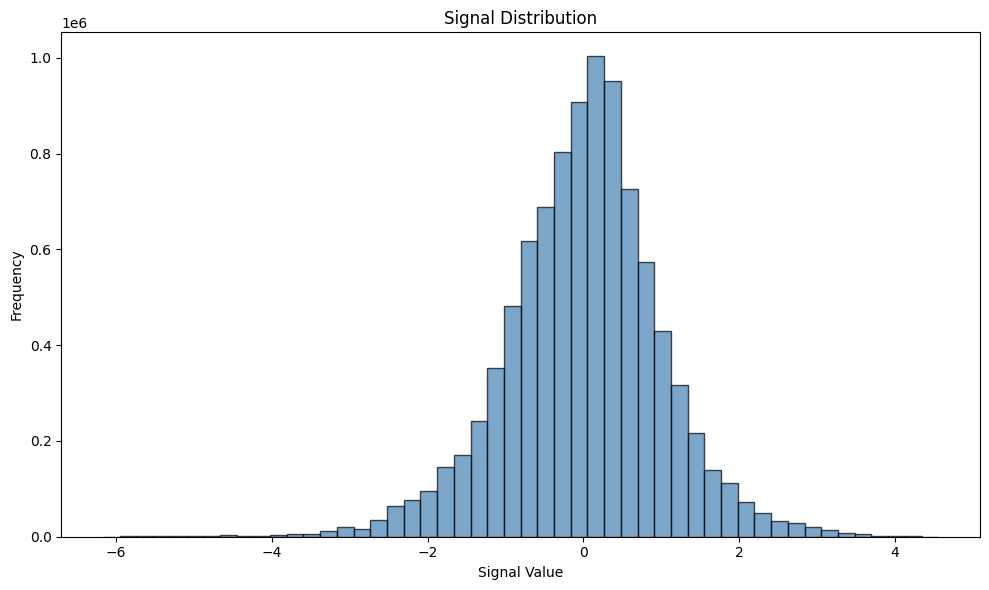

In [53]:
# sfr.get_signal_distribution(signal)
sfr.get_signal_distribution(industry_momentum, column='score')

## 4. Validation Checks ?

Verify signal quality and identify any issues before implementation.

## 5. Next Steps

When satisfied with your signal:

1. **Copy** your data loading and signal calculation logic to `create_signal.py`
2. **Run** `uv run create-signal` to save the signal to `data/signal.parquet`
3. **Open** `uv run ew-dash` to analyze the signal before backtesting